# Stellar Evolution and 1G BH Masses

In [1]:
import warnings
warnings.filterwarnings('ignore', 'Wswiglal-redir-stdio')

from gwGenealogy.stellar import (
    IMF_kroupa, sample_kroupa_masses,
    sample_zams_masses, evolve_stars,
    sample_1g_bh_masses_from_stellar_collapse,
    sample_maxwellian_kick,
)
from gwGenealogy.utils import set_rcparams
import numpy as np
import matplotlib.pyplot as plt

set_rcparams()

lal.MSUN_SI != Msun


## Kroupa IMF

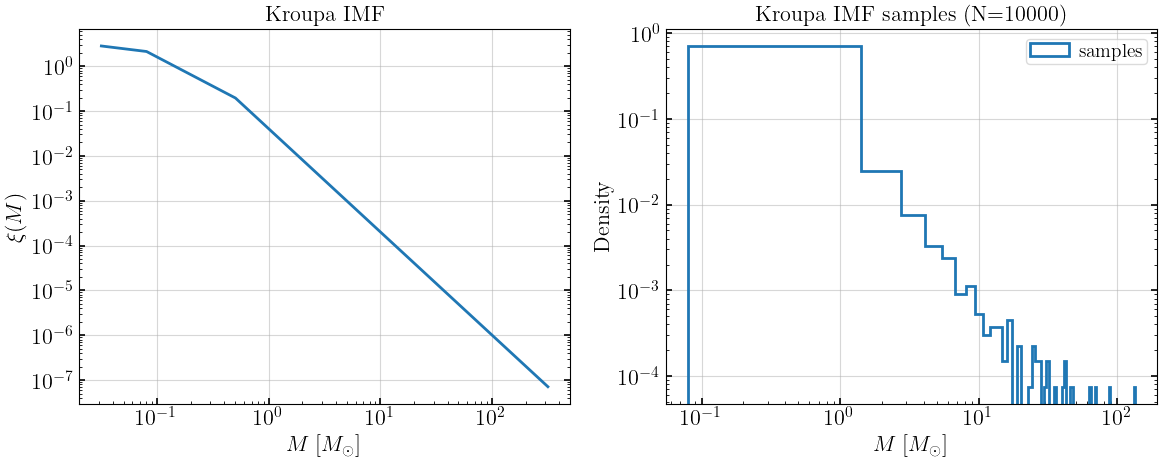

In [2]:
m = np.logspace(-1.5, 2.5, 5000)
imf_values = IMF_kroupa(m)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Analytic IMF
axes[0].loglog(m, imf_values, lw=2)
axes[0].set_xlabel(r'$M\;[M_\odot]$')
axes[0].set_ylabel(r'$\xi(M)$')
axes[0].set_title('Kroupa IMF')

# Sampled masses
sampled_masses = sample_kroupa_masses(10000, m_min=0.08, m_max=150, seed=42)
axes[1].hist(sampled_masses, bins=100, density=True, histtype='step', lw=2, label='samples')
axes[1].set_xlabel(r'$M\;[M_\odot]$')
axes[1].set_ylabel('Density')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Kroupa IMF samples (N=10000)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Stellar evolution: ZAMS to BH remnant

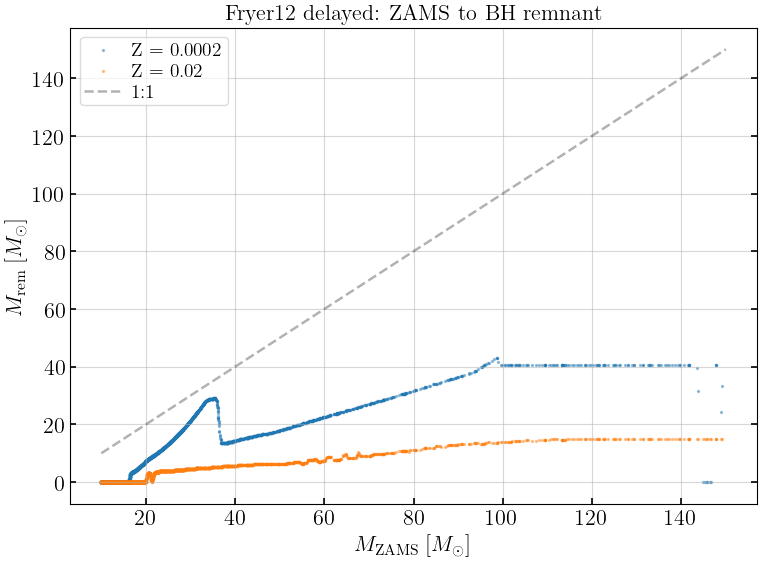

In [3]:
m_zams = sample_zams_masses(5000, m_zams_min=10, m_zams_max=150, imf='kroupa', seed=42)

m_rem_lowZ  = evolve_stars(m_zams, Z=0.0002, model='Fryer12_delayed')
m_rem_highZ = evolve_stars(m_zams, Z=0.02,   model='Fryer12_delayed')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(m_zams, m_rem_lowZ,  s=2, alpha=0.4, label='Z = 0.0002')
ax.scatter(m_zams, m_rem_highZ, s=2, alpha=0.4, label='Z = 0.02')
ax.plot([10, 150], [10, 150], 'k--', alpha=0.3, label='1:1')
ax.set_xlabel(r'$M_{\rm ZAMS}\;[M_\odot]$')
ax.set_ylabel(r'$M_{\rm rem}\;[M_\odot]$')
ax.set_title('Fryer12 delayed: ZAMS to BH remnant')
ax.legend()
plt.tight_layout()
plt.show()

## SEVN delayed model

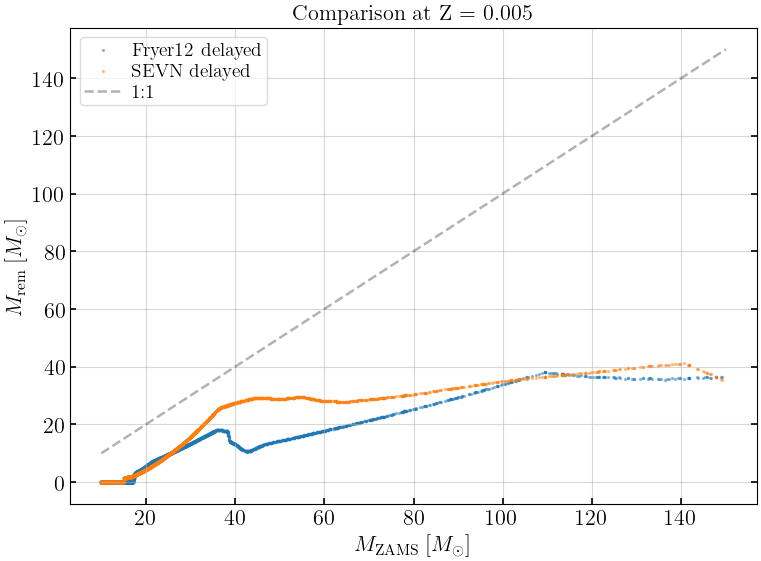

In [4]:
m_rem_sevn = evolve_stars(m_zams, Z=0.005, model='SEVN_delayed')
m_rem_f12  = evolve_stars(m_zams, Z=0.005, model='Fryer12_delayed')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(m_zams, m_rem_f12,  s=2, alpha=0.4, label='Fryer12 delayed')
ax.scatter(m_zams, m_rem_sevn, s=2, alpha=0.4, label='SEVN delayed')
ax.plot([10, 150], [10, 150], 'k--', alpha=0.3, label='1:1')
ax.set_xlabel(r'$M_{\rm ZAMS}\;[M_\odot]$')
ax.set_ylabel(r'$M_{\rm rem}\;[M_\odot]$')
ax.set_title('Comparison at Z = 0.005')
ax.legend()
plt.tight_layout()
plt.show()

## 1G BH mass pool

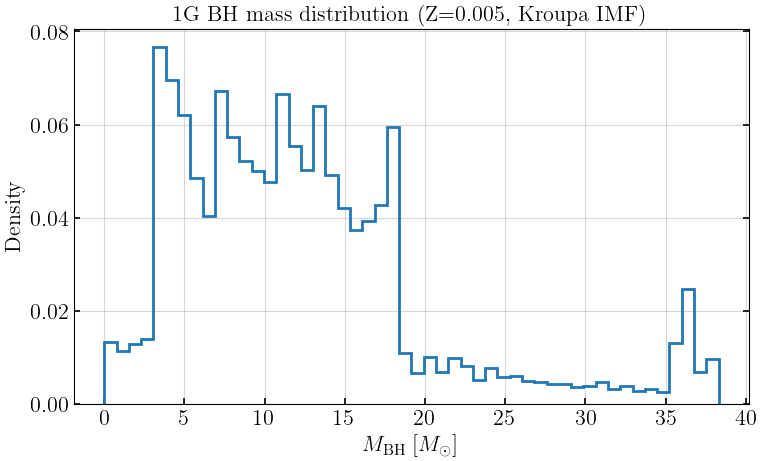

Median BH mass: 11.06 Msun
Min BH mass:    0.01 Msun
Max BH mass:    38.30 Msun


In [5]:
bh_masses = sample_1g_bh_masses_from_stellar_collapse(
    10000, Z=0.005, imf='kroupa', m_zams_min=10, m_zams_max=150, seed=42
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(bh_masses, bins=50, density=True, histtype='step', lw=2)
ax.set_xlabel(r'$M_{\rm BH}\;[M_\odot]$')
ax.set_ylabel('Density')
ax.set_title('1G BH mass distribution (Z=0.005, Kroupa IMF)')
plt.tight_layout()
plt.show()

print(f"Median BH mass: {np.median(bh_masses):.2f} Msun")
print(f"Min BH mass:    {np.min(bh_masses):.2f} Msun")
print(f"Max BH mass:    {np.max(bh_masses):.2f} Msun")

## Natal kicks

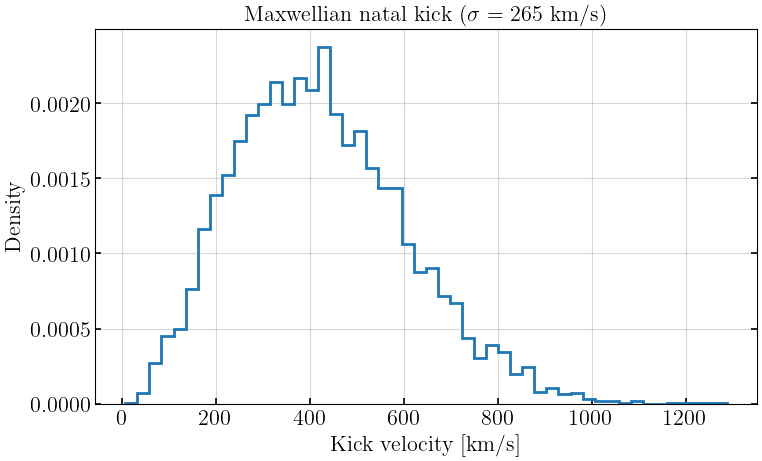

Mean kick: 423.6 km/s


In [6]:
kicks = sample_maxwellian_kick(sigma=265, n_samples=5000, seed=42)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(kicks, bins=50, density=True, histtype='step', lw=2)
ax.set_xlabel('Kick velocity [km/s]')
ax.set_ylabel('Density')
ax.set_title(r'Maxwellian natal kick ($\sigma = 265$ km/s)')
plt.tight_layout()
plt.show()

print(f"Mean kick: {np.mean(kicks):.1f} km/s")